# This is a notebook specified on drawing the unbinned fit on A/E spectrum from different filter Kernels

In [1]:
from pytools4scarf import dataloader
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [2]:
from pathlib import Path
runs = [
    's20ns_mw5',  's20ns_mw7',
    's30ns_mw3',  's30ns_mw5',  's30ns_mw7',
    's40ns_mw1',  's40ns_mw3',  's40ns_mw5',  's40ns_mw7',
    's50ns_mw1',  's50ns_mw3',  's50ns_mw5',  's50ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
]

map_dir = Path(
    "/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
)
def map_path(config):
    map_dir ="/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
    return map_dir+"/map_calibration_"+config+".yaml"
data_cleaning_path = (
    "/mnt/atlas02/users/leoli/self_metadata/data_cleaning.yaml"
)
map_path('s100ns_mw5')

'/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs/map_calibration_s100ns_mw5.yaml'

In [29]:
run= "s100ns_mw5"

In [30]:
dfs_evt,lts_evt = {},{}
dfs_evt["r059"], lts_evt["r059"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)

In [31]:
dfs_phy_evt = dfs_evt['r059']['ch002']

In [32]:
argon_veto = np.asarray(dfs_phy_evt.is_lar_vetoed)
muon_veto = np.asarray(dfs_phy_evt.is_muon)
alpha_veto = np.asarray(dfs_phy_evt.A_max_o_E_High_Side_Cut & (dfs_phy_evt.Iasy<0))

In [33]:
dfs_1, lts_1 = {}, {}
dfs_1["r059"], lts_1["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(run),
    data_cleaning_path,
    "hit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)

In [34]:
dfs_phy = dfs_1['r059']['ch002']

In [35]:
E_1=np.asarray(dfs_phy.trapEmax_fix_cal)
A_max_mw_o_E_fix_Classifier = np.asarray(dfs_phy.A_max_mw_o_E_fix_Classifier)
is_valid_waveform_1 = np.asarray(dfs_phy.is_valid_waveform)

In [36]:
import pickle 
with open("/mnt/atlas02/users/leoli/AoverE_analysis/both_sided_cuts/survival_db_from_dataprod.pkl", "rb") as f:
    survival_db = pickle.load(f)
ROI_mask = (E_1 > 1839) & (E_1 < 2239)
cut_value= survival_db[run]['cut_value_90']

In [48]:
# Check that all arrays correspond to the same events
assert (
    A_max_mw_o_E_fix_Classifier.shape
    == ROI_mask.shape
    == argon_veto.shape
    # == low_cut_1.shape
    # == low_cut_2.shape
), (
    f"Shape mismatch: "
    f"A_max_mw_o_E_Classifier_1={A_max_mw_o_E_fix_Classifier.shape}, "
    f"ROI_mask={ROI_mask.shape}, "
    # f"low_cut_1={low_cut_1.shape}, "
    # f"low_cut_2={low_cut_2.shape}"
)

# ROI selection plus finite classifier values
selection = (
    ROI_mask
    & np.isfinite(A_max_mw_o_E_fix_Classifier)
    # & np.isfinite(A_max_mw_o_E_Classifier_2)
    # & ~argon_veto
    & ~muon_veto
    & alpha_veto
)

# Selected classifier values
aoe_clean = A_max_mw_o_E_fix_Classifier[selection]

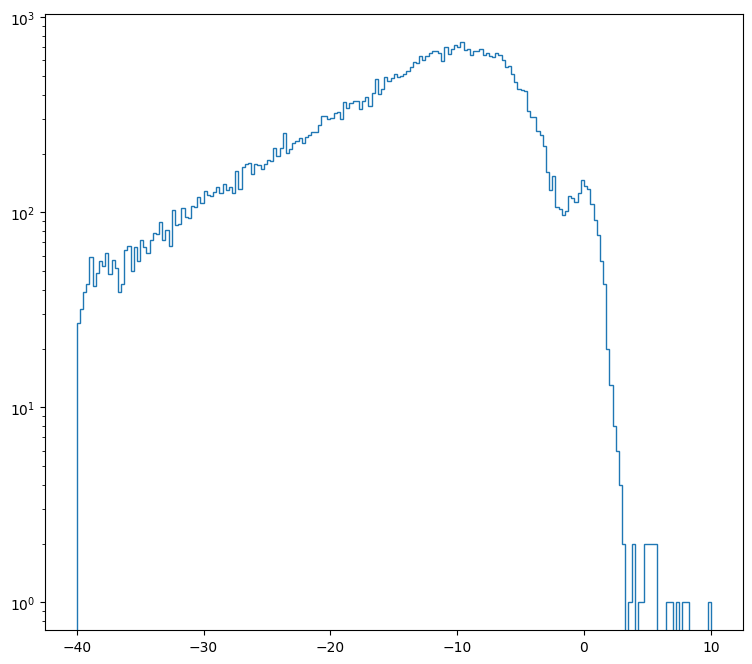

In [49]:
fig,ax = plt.subplots(figsize=(9, 8))
range=(-40,10)
ax.hist(aoe_clean,bins=200,range=range,histtype='step')
ax.set_yscale('log')
